# Optimización de Oferta en CABA
### Caso de Estudio: Localización de Hubs para DiDi Inex

1. **Objetivo:** Identificar puntos estratégicos de posicionamiento preventivo de conductores en la Ciudad de Buenos Aires. 
2. **Metodología:** Se utiliza el dataset de paradas de taxis oficiales (proxy de demanda histórica) y se aplica un algoritmo de **K-Means Clustering** para resolver un problema de **Location-Allocation** (Investigación Operativa).

In [18]:
import pandas as pd
import re
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import folium
import networkx as nx

import warnings
warnings.filterwarnings('ignore')

## 1. Preparación de Datos (ETL)
Extraemos las coordenadas geográficas de la columna `geometry` para poder operar vectorialmente con los puntos de la ciudad.

In [14]:
# Carga del dataset de paradas de taxis de CABA
df = pd.read_csv('datasets/paradas_taxis.csv')

def extract_coords(geometry):
    # El formato original es POINT (longitud latitud)
    coords = re.findall(r"[-+]?\d*\.\d+|\d+", geometry)
    return float(coords[1]), float(coords[0])

# Generamos columnas limpias de Latitud y Longitud
df[['lat', 'lon']] = df['geometry'].apply(lambda x: pd.Series(extract_coords(x)))

print(f"Total de puntos analizados: {len(df)}")
df[['barrio', 'lat', 'lon']].head()

Total de puntos analizados: 333


,barrio,lat,lon
0,Flores,-34.627642,-58.463176
1,Villa Crespo,-34.602255,-58.432643
2,Villa Crespo,-34.600265,-58.447319
3,Flores,-34.631550,-58.469374
4,San Nicolas,-34.603021,-58.369557


## 2. Modelado de Investigación Operativa
Utilizamos **K-Means** para identificar los 10 "centros de gravedad" de la oferta existente. 
Este análisis minimiza la distancia total entre cualquier parada de taxi (demanda) y el Hub de DiDi más cercano (oferta), optimizando el **ETA (Time of Arrival)** proyectado.

In [15]:
# Definimos 10 clústeres estratégicos
K_HUBS = 10
kmeans = KMeans(n_clusters=K_HUBS, random_state=42, n_init=10)

# Asignamos cada parada a un clúster y calculamos los centroides (Hubs)
df['cluster'] = kmeans.fit_predict(df[['lat', 'lon']])
hubs = kmeans.cluster_centers_

print("Coordenadas de los Hubs Estratégicos generadas correctamente.")

Coordenadas de los Hubs Estratégicos generadas correctamente.


## 3. Visualización Geográfica Interactiva
Generamos un mapa utilizando la capa de **CartoDB Positron** para facilitar la lectura urbana.  
- Los <span style="color: skyblue;">**puntos azules**</span> representan la infraestructura de transporte actual.  
- Los <span style="color: red;"> **marcadores rojos** </span> representan los Hubs sugeridos para el despliegue de conductores de DiDi.

In [16]:
# Crear el mapa centrado en el Obelisco
mapa_caba = folium.Map(location=[-34.6037, -58.3816], zoom_start=12, tiles='CartoDB positron')

# Capa de paradas actuales
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=2,
        color='skyblue',
        fill=True,
        fill_color='skyblue',
        popup=f"Barrio: {row['barrio']}"
    ).add_to(mapa_caba)

# Capa de Hubs de Expansión (DiDi)
for i, hub in enumerate(hubs):
    folium.Marker(
        location=[hub[0], hub[1]],
        icon=folium.Icon(color='red', icon='car', prefix='fa'), # Cambié el icono a un auto
        popup=f'Hub de Expansión {i+1}'
    ).add_to(mapa_caba)

# Guardar resultado para presentación externa
mapa_caba.save('mapa_estrategico_didi.html')

# Mostrar mapa en el notebook
mapa_caba

## Conclusiones 
1. **Focalización de Recursos:** En lugar de saturar toda la ciudad, la operación debería centrarse en los 10 nodos identificados para garantizar confiabilidad del servicio.
2. **Ventaja Competitiva:** Estos hubs permiten a los competidores posicionarse preventivamente en zonas donde el sistema de taxis ya validó una alta rotación de pasajeros.
3. **Escalabilidad:** Este modelo es replicable para el lanzamiento en otras plazas (Córdoba, Rosario) utilizando datos de movilidad locales.

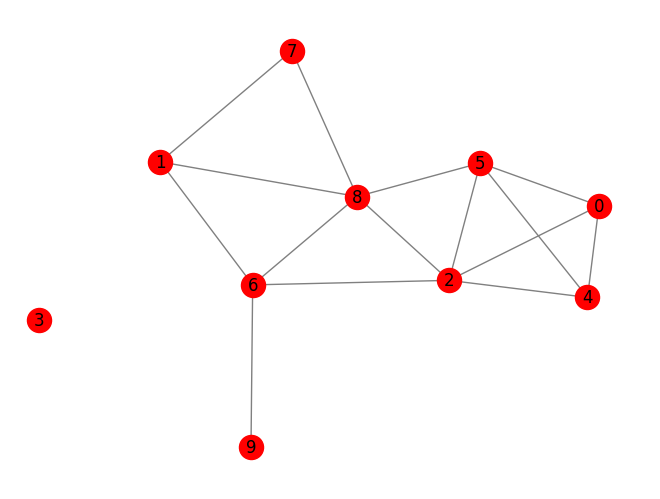

In [19]:
# Creamos un grafo donde los nodos son tus 10 Hubs
G = nx.Graph()

for i, hub in enumerate(hubs):
    G.add_node(i, pos=(hub[1], hub[0])) # lon, lat

# Conectamos nodos que están a menos de una distancia umbral (ej. 3km)
# Esto simula la capacidad de un conductor de saltar de un hub a otro
from scipy.spatial.distance import cdist
dist_matrix = cdist(hubs, hubs, metric='euclidean')

for i in range(len(hubs)):
    for j in range(i + 1, len(hubs)):
        if dist_matrix[i, j] < 0.05: # Umbral aproximado en grados
            G.add_edge(i, j, weight=dist_matrix[i, j])

# Dibujar el esqueleto de la red de expansión
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='red', edge_color='gray')

## Conclusiones Estratégicas: Sistemas de Redes Dinámicas

Este análisis trasciende el caso de una empresa puntual y establece un marco de trabajo para cualquier sistema de logística urbana:

1. **De Puntos a Redes:** La eficiencia no depende de la ubicación aislada de los activos, sino de la **capilaridad de la red**. Un nodo con alta centralidad permite una respuesta más ágil ante imprevistos en barrios vecinos.
2. **Resiliencia Operativa:** Modelar la ciudad como un grafo permite identificar "puntos de fallo único". Si un nodo central se satura, el grafo nos muestra las rutas alternativas para redistribuir la carga.
3. **Escalabilidad Matemática:** Este modelo es agnóstico al territorio. La combinación de **Unsupervised Learning (K-Means)** y **Topología de Redes (Grafos)** proporciona una ventaja competitiva en el diseño de cualquier sistema de expansión internacional, permitiendo que la toma de decisiones sea impulsada por la estructura matemática de la ciudad y no por la intuición.